In [72]:
# run the regressions for the clinical outcomes project - first for loading parameters, then on the CoM matrices
import os
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# go to working directory
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/ICA_Results/Depression_ICA_Analyses_Clinical_Outcomes')

# Load MATLAB workspace
data = loadmat('Clinical_Outcomes_Workspace.mat')

print(data.keys())

# --- Load variables ---
depind = data['depind']                    # 2743 x 68
hcind = data['hcind']
age = data['age'].ravel()
Location_ID = data['Location_ID'].ravel()
sex_coded = data['sex_coded'].ravel()
worry_rumination = data['Worry_Rumination'].ravel()
moodiness = data['Moodiness'].ravel()
social_disinterest = data['Social_Disinterest'].ravel()
all_matrices_dep = data['all_matrices_dep']

# --- FIX: Load Labels correctly ---
# MATLAB often stores strings as nested arrays of dtype=object
if 'Labels' in data:
    Labels = data['Labels']
    clean_labels = [str(lbl[0]) for lbl in Labels.squeeze()]
else:
    clean_labels = None
    print("⚠️ WARNING: 'Labels' not found in .mat file")

print(clean_labels)

# --- Sanity checks ---
print(depind.shape)
print(hcind.shape)

# --- Build DataFrame for regression ---
df = pd.DataFrame({
    "age": age,
    "Location_ID": Location_ID,
    "sex_coded": sex_coded,
    "worry_rumination": worry_rumination,
    "moodiness": moodiness,
    "social_disinterest": social_disinterest
})

# Add loading columns
for i in range(68):
    df[f"loading_{i+1}"] = depind[:, i]


/opt/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


dict_keys(['__header__', '__version__', '__globals__', 'Adjustment_Disorder', 'Alcohol_Related_Disorder', 'Amnestic_disorders', 'Amphetamine_Related_Disorder', 'Anorexia_Nervosa', 'Antisocial_Personality_Disorder', 'Anxiety_Disorder', 'Aspergers', 'Attention_Deficit_Disruptive_Behavior', 'Attention_Deficit_hyperactivity', 'Autism', 'Autonomic_HotCold_Flashes', 'Avoidant_Personality_Disorder', 'BSC_100_Having_dark_thoughts_ones_that_may_involve_suicidal_or_', 'BSC_101_Experiencing_periods_of_forgetfulness_or_memory_problem', 'BSC_10_Having_poor_planning_skills', 'BSC_11_Lacking_clear_goals_or_forward_thinking', 'BSC_12_Having_difficulty_expressing_feelings', 'BSC_13_Having_difficulty_expressing_empathy_for_others', 'BSC_14_Experiencing_excessive_daydreaming', 'BSC_15_Feeling_bored', 'BSC_16_Feeling_apathetic_or_unmotivated', 'BSC_17_Feeling_tired_sluggish_or_slow_moving', 'BSC_18_Feeling_spacey_or_in_a_fog', 'BSC_19_Feeling_fidgety_restless_or_trouble_sitting_still', 'BSC_1_Failing_to_g

In [74]:
#go to working directory and load data frame aka the .csv file
#load factor scores from this
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/clinical outcomes measures')
df = pd.read_csv("depression_cov_dx_symp_rest_conc_matched_qc_totalbrain(in)_factors.csv")
print(df.columns.tolist()) #print headers of each variable so I can load correctly

['CID', 'Location_ID', 'age', 'sex_coded', 'dx', 'conc_filename', 'rest_filename', 'Hallucinogen_related_disorders', 'Borderline', 'Eating_Disorder_unspecified', 'Passive_Aggressive_Personality_Disorder', 'Mood_Disorder_NOS', 'Amnestic_disorders', 'Opioid_Related_Disorder', 'SubstanceAbuseDisorder', 'Factitious_disorder', 'Elimination_Disorder', 'Aspergers', 'Cannabis_Related_Disorder', 'Toxicicity_Encephalopathy', 'frontotemporal_dementia', 'Depression_NOS', 'Dissociative_Disorder', 'Cocaine_Related_Disorder', 'Vascular_dementia', 'Somatoform_disorders', 'Depressive_Disorder', 'Personallity_Cluster_A', 'Amphetamine_Related_Disorder', 'Disruptive_Behavior', 'TemporalDysfunction', 'Mathematics_disorder', 'Bipolar_Disorder', 'Antisocial_Personality_Disorder', 'Caffeine_related_disorders', 'Schizoid_Personality_Disorder', 'Learning_Disorder', 'Personality_Disorder_NOS', 'dysgraphia', 'Nicotine_related_disorders', 'Polysubstance_related_disorder', 'BrainTrauma', 'Substance_dependence', 'Bu

In [75]:
import pandas as pd

# Ensure each variable is 1‑D
worry_rumination = worry_rumination.squeeze()
moodiness = moodiness.squeeze()
social_disinterest = social_disinterest.squeeze()

print(worry_rumination.shape)
print(moodiness.shape)
print(social_disinterest.shape)

# Build DataFrame
df = pd.DataFrame({
    'Worry_Rumination': worry_rumination,
    'Moodiness': moodiness,
    'Social_Disinterest': social_disinterest
})

# Correlation matrix
correlation_matrix = df.corr()
correlation_matrix


(2743,)
(2743,)
(2743,)


,Worry_Rumination,Moodiness,Social_Disinterest
Worry_Rumination,1.000000,-0.019811,-0.058648
Moodiness,-0.019811,1.000000,-0.011493
Social_Disinterest,-0.058648,-0.011493,1.000000


In [76]:
# run regressions for depression loading parameters

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from statsmodels.stats.multitest import multipletests

# Add each loading column to df
for i in range(68):
    df[f"loading_{i+1}"] = depind[:, i]

# Storage lists
p_worry = []
T_worry = []
p_mood = []
T_mood = []
p_social = []
T_social = []

for i in range(68):
    loading = f"loading_{i+1}"

    # ANCOVA model including all 3 variables
    formula = (
        f"{loading} ~ age + C(sex_coded) + C(Location_ID) + "
        f"worry_rumination + moodiness + social_disinterest"
    )

    model = ols(formula, data=df).fit()

    # Extract p-values (from ANOVA table)
    anova = sm.stats.anova_lm(model, typ=2)

    p_worry.append(float(anova.loc["worry_rumination", "PR(>F)"]))
    p_mood.append(float(anova.loc["moodiness", "PR(>F)"]))
    p_social.append(float(anova.loc["social_disinterest", "PR(>F)"]))

    # Extract T-statistics (from model coefficients)
    T_worry.append(float(model.tvalues["worry_rumination"]))
    T_mood.append(float(model.tvalues["moodiness"]))
    T_social.append(float(model.tvalues["social_disinterest"]))

# --- FDR correction (Benjamini–Hochberg) ---
q_worry = multipletests(p_worry, method='fdr_bh')[1]
q_mood = multipletests(p_mood, method='fdr_bh')[1]
q_social = multipletests(p_social, method='fdr_bh')[1]

# Build results table
results = pd.DataFrame({
    "Loading": np.arange(1, 69),
    "p_worry": p_worry,
    "q_worry": q_worry,
    "T_worry": T_worry,
    "p_mood": p_mood,
    "q_mood": q_mood,
    "T_mood": T_mood,
    "p_social": p_social,
    "q_social": q_social,
    "T_social": T_social
})

print(results)


    Loading   p_worry   q_worry   T_worry    p_mood    q_mood    T_mood  \
0         1  0.006910  0.041626  2.703499  0.504516  0.897409 -0.667502   
1         2  0.001267  0.023617  3.227137  0.004818  0.109210 -2.821603   
2         3  0.001600  0.023617  3.159607  0.074354  0.474947 -1.785213   
3         4  0.008370  0.043783  2.638961  0.027333  0.309778 -2.208086   
4         5  0.029551  0.095689  2.177370  0.007211  0.122591 -2.689252   
..      ...       ...       ...       ...       ...       ...       ...   
63       64  0.334592  0.533491  0.965102  0.368168  0.807594 -0.900082   
64       65  0.631269  0.727564 -0.480004  0.793428  0.951645 -0.261892   
65       66  0.530788  0.622303  0.626895  0.514691  0.897409 -0.651649   
66       67  0.882965  0.898997  0.147227  0.803131  0.951645 -0.249325   
67       68  0.086829  0.168696  1.713077  0.992242  0.999658 -0.009725   

    p_social  q_social  T_social  
0   0.046449  0.197409  1.992328  
1   0.003603  0.046667  2.913

['cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-IT',
 'HC-IT',
 'HC-IT',
 'SC-BG',
 'SC-BG',
 'SC-EH',
 'SC-EH',
 'SC-EH',
 'SC-EH',
 'SC-ET',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-SA',
 'TN-SA',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC']

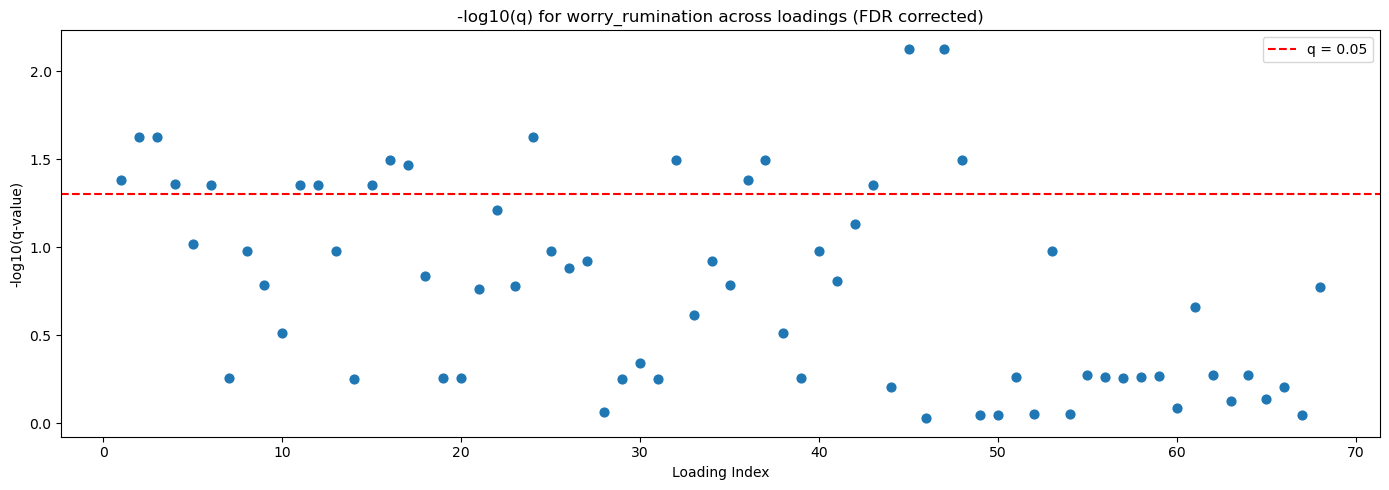

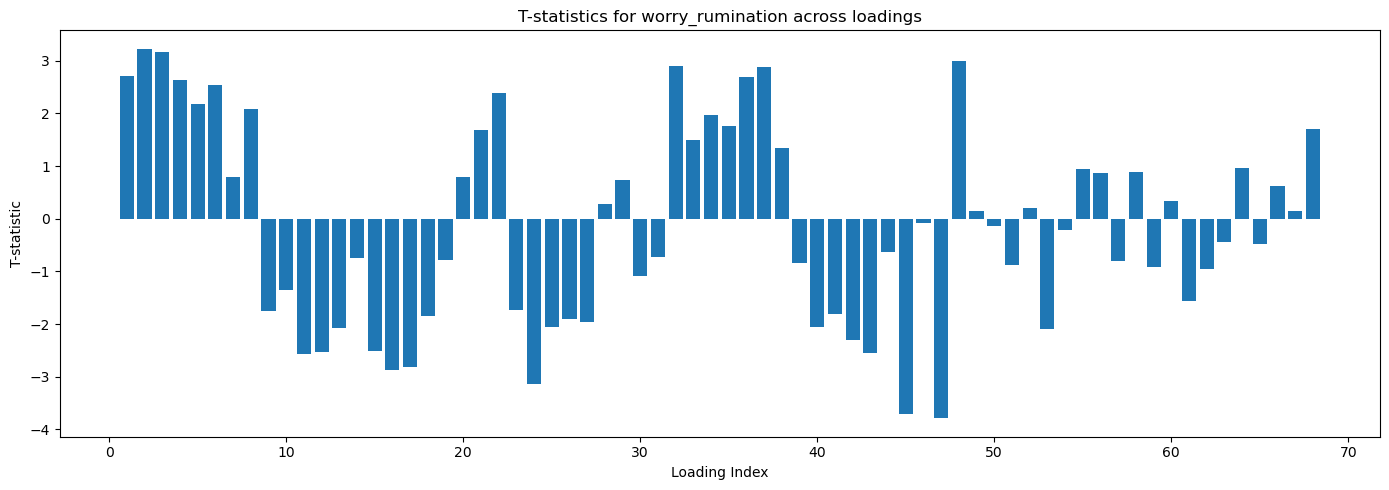

    Loading   p_worry   q_worry   T_worry    p_mood    q_mood    T_mood  \
0         1  0.006910  0.041626  2.703499  0.504516  0.897409 -0.667502   
1         2  0.001267  0.023617  3.227137  0.004818  0.109210 -2.821603   
2         3  0.001600  0.023617  3.159607  0.074354  0.474947 -1.785213   
3         4  0.008370  0.043783  2.638961  0.027333  0.309778 -2.208086   
5         6  0.011168  0.044412  2.539376  0.002847  0.096810 -2.986863   
10       11  0.010341  0.044412 -2.566268  0.072024  0.474947  1.799766   
11       12  0.011678  0.044412 -2.523692  0.108965  0.559012  1.603465   
14       15  0.011756  0.044412 -2.521326  0.444599  0.839798  0.764577   
15       16  0.004210  0.031805 -2.864784  0.605991  0.930291  0.515874   
16       17  0.004980  0.033865 -2.810935  0.240027  0.680076  1.175214   
23       24  0.001737  0.023617 -3.135508  0.872991  0.957474  0.159878   
31       32  0.003805  0.031805  2.896765  0.002679  0.096810 -3.005534   
35       36  0.007346  0.

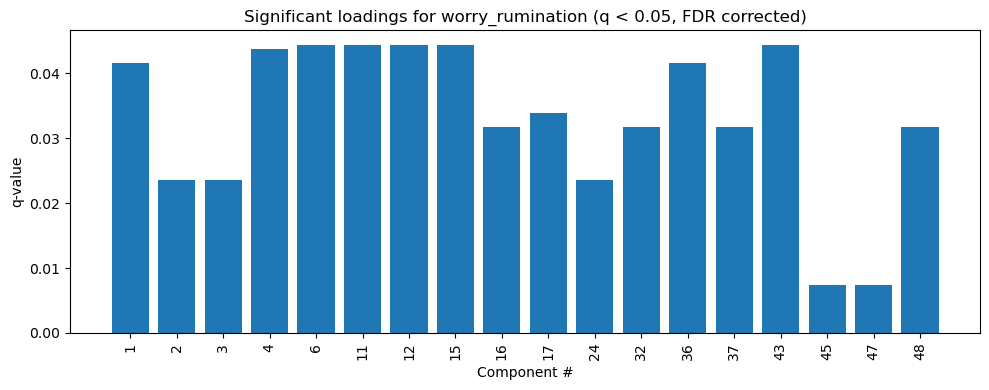

    Loading   p_worry   q_worry   T_worry    p_mood    q_mood    T_mood  \
44       45  0.000219  0.007437 -3.702031  0.615634  0.930291  0.502114   
46       47  0.000155  0.007437 -3.788998  0.741015  0.949427 -0.330549   

    p_social  q_social  T_social  
44  0.054749  0.202713 -1.921807  
46  0.946188  0.960311 -0.067501  


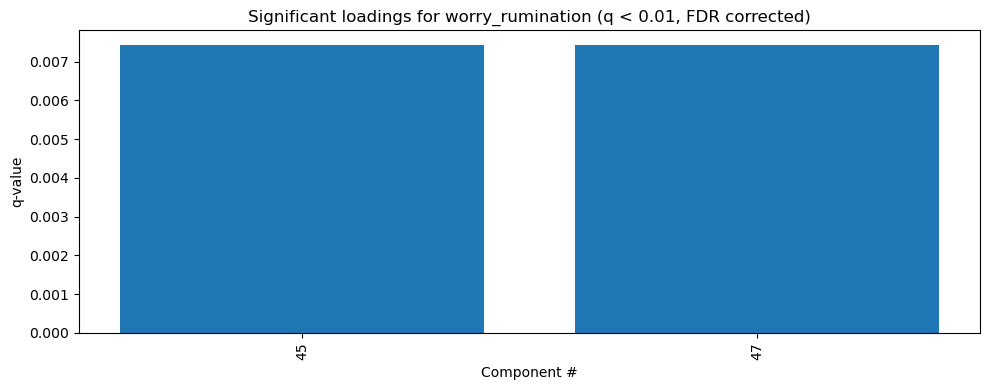

In [77]:
#plot 1st plot for factor: worry_rumination FDR corrected
#check labels variable
display(clean_labels) #check as a sanity check

import matplotlib.pyplot as plt
import numpy as np

# Ensure no zero q-values (avoid -log10(0) crash)
results["q_worry"] = results["q_worry"].replace(0, 1e-300)

# --- LOG PLOT (worry, q-values) ---
plt.figure(figsize=(14, 5))
plt.scatter(results["Loading"], -np.log10(results["q_worry"]), s=40)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", label="q = 0.05")
plt.xlabel("Loading Index")
plt.ylabel("-log10(q-value)")
plt.title("-log10(q) for worry_rumination across loadings (FDR corrected)")
plt.legend()
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (worry) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_worry"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for worry_rumination across loadings")
plt.tight_layout()
plt.show()


# --- SIGNIFICANT LOADINGS q < 0.05 ---
sig = results[results["q_worry"] < 0.05]
print(sig)

sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_worry"])
plt.xticks(rotation=90)
plt.title("Significant loadings for worry_rumination (q < 0.05, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

# --- SIGNIFICANT LOADINGS q < 0.01 ---
sig = results[results["q_worry"] < 0.01]
print(sig)

sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_worry"])
plt.xticks(rotation=90)
plt.title("Significant loadings for worry_rumination (q < 0.01, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

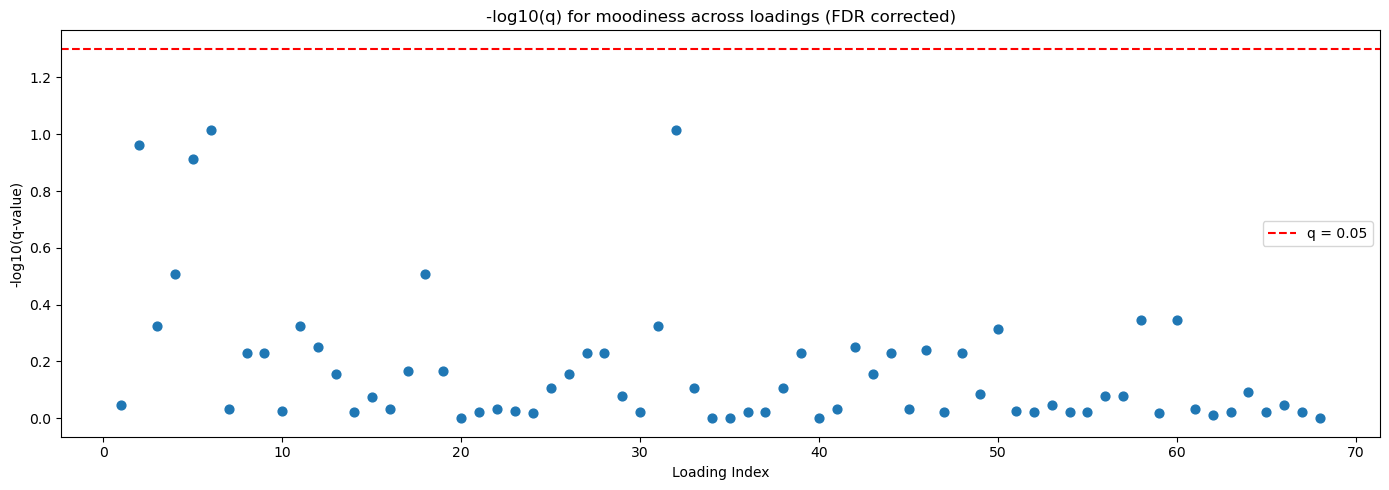

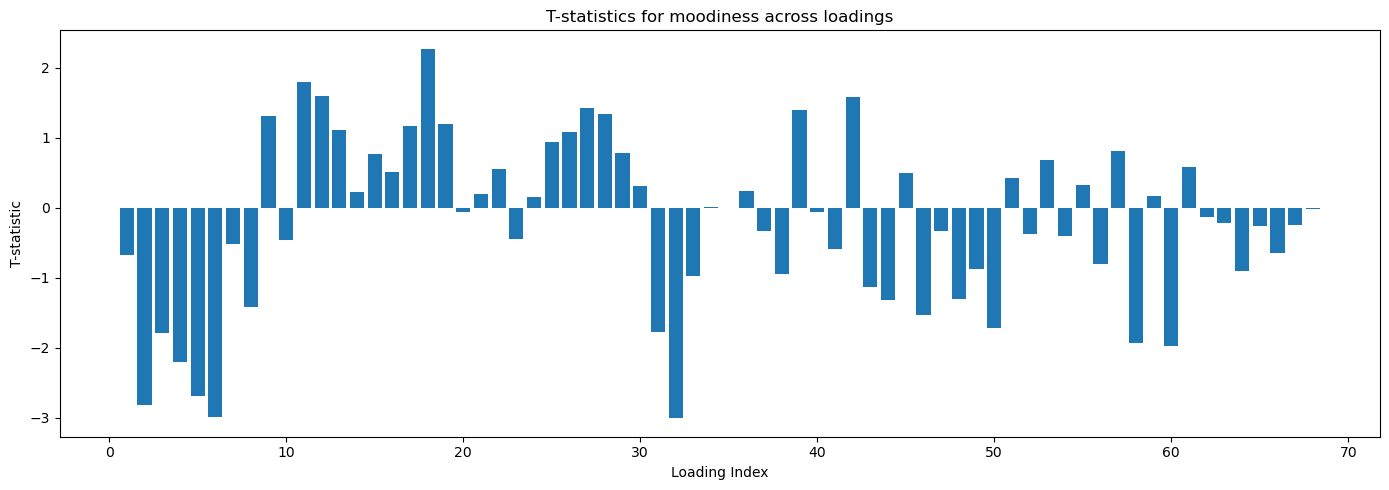

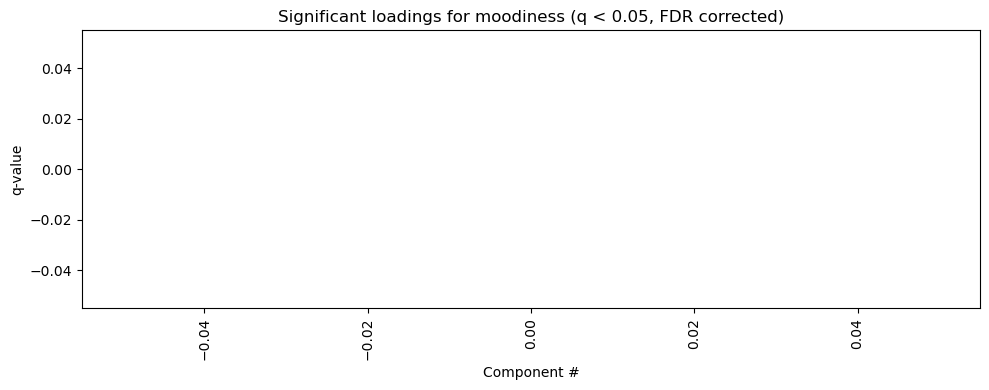

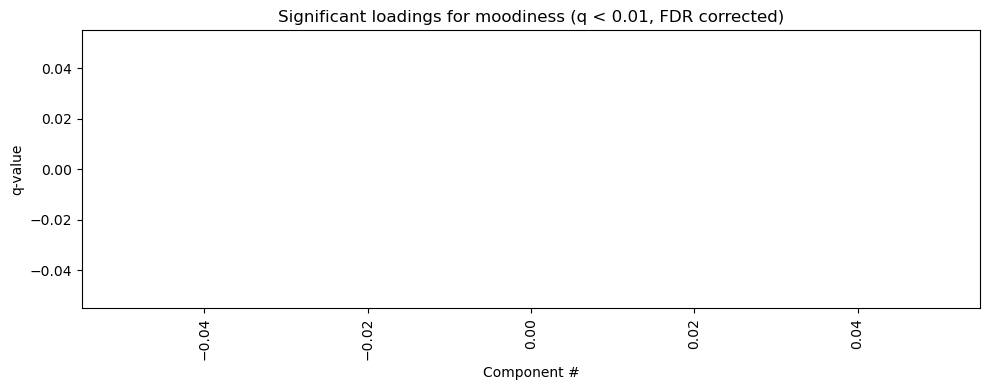

In [78]:
#plot 2nd plot with moodiness 

import matplotlib.pyplot as plt
import numpy as np

# Ensure no zero q-values (avoid -log10(0) crash)
results["q_mood"] = results["q_mood"].replace(0, 1e-300)

# --- LOG PLOT (moodiness, q-values) ---
plt.figure(figsize=(14, 5))
plt.scatter(results["Loading"], -np.log10(results["q_mood"]), s=40)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", label="q = 0.05")
plt.xlabel("Loading Index")
plt.ylabel("-log10(q-value)")
plt.title("-log10(q) for moodiness across loadings (FDR corrected)")
plt.legend()
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (moodiness) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_mood"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for moodiness across loadings")
plt.tight_layout()
plt.show()

# --- Significant q < 0.05 ---
sig = results[results["q_mood"] < 0.05]
sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_mood"])
plt.xticks(rotation=90)
plt.title("Significant loadings for moodiness (q < 0.05, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

# --- Significant q < 0.01 ---
sig = results[results["q_mood"] < 0.01]
sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_mood"])
plt.xticks(rotation=90)
plt.title("Significant loadings for moodiness (q < 0.01, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()


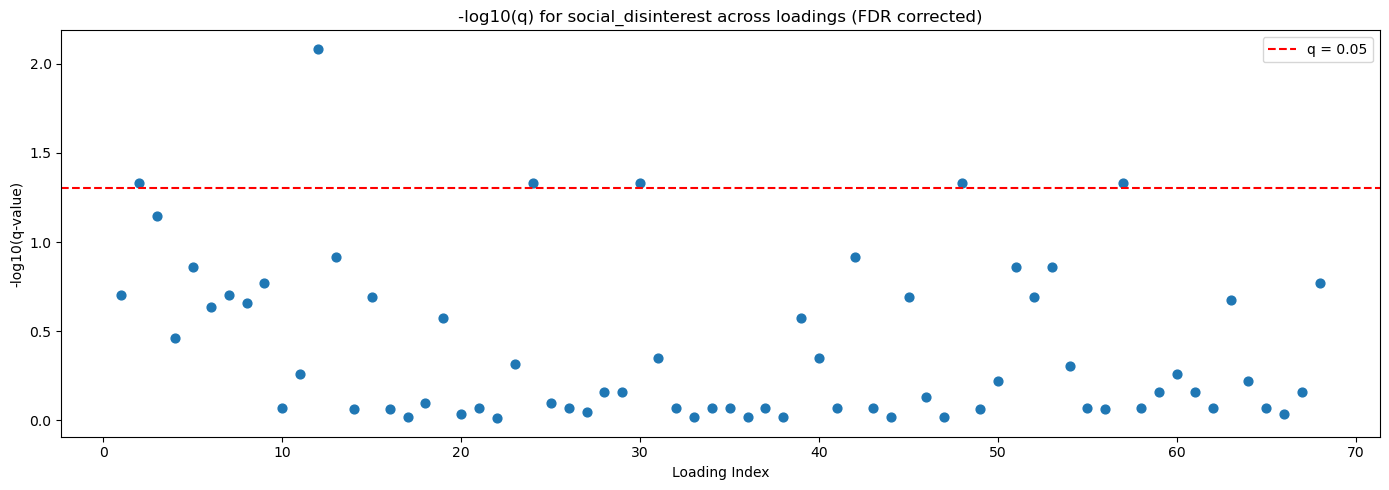

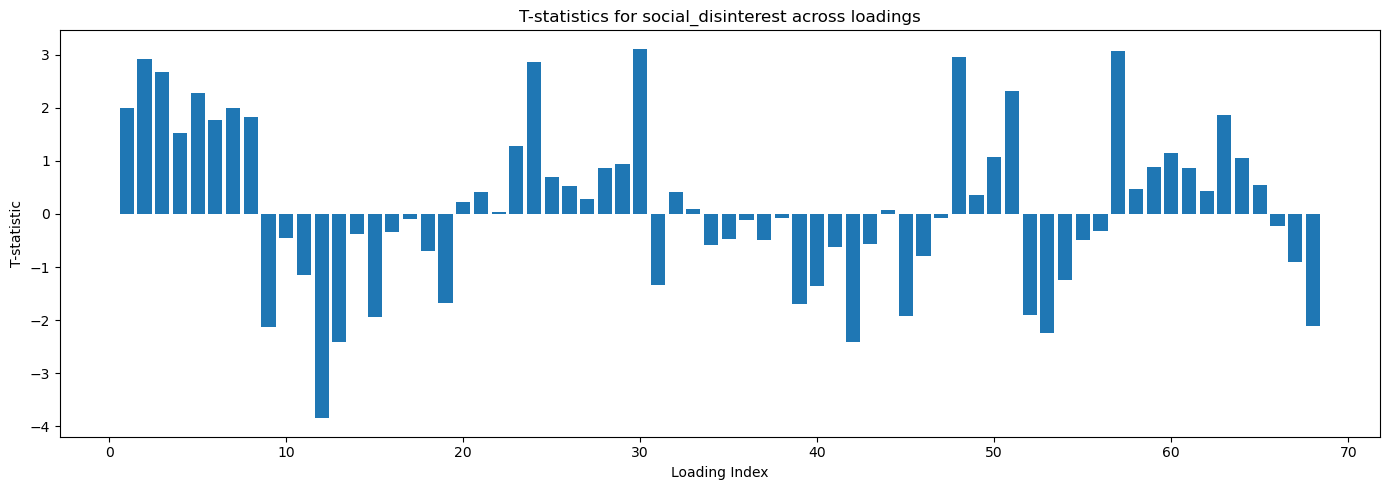

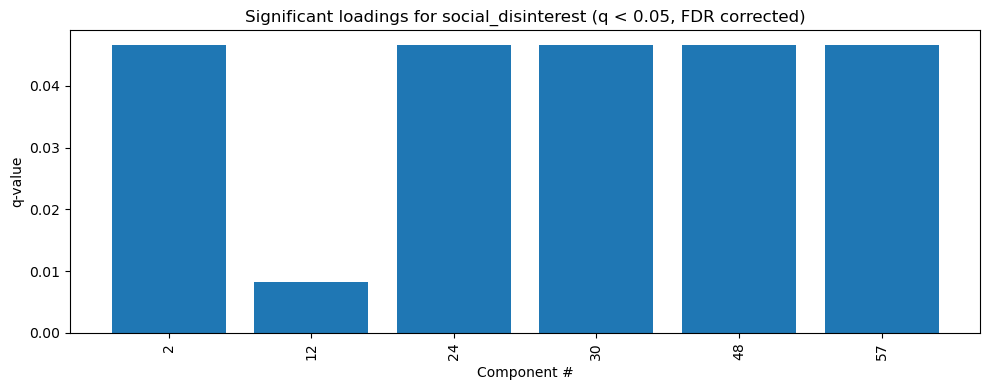

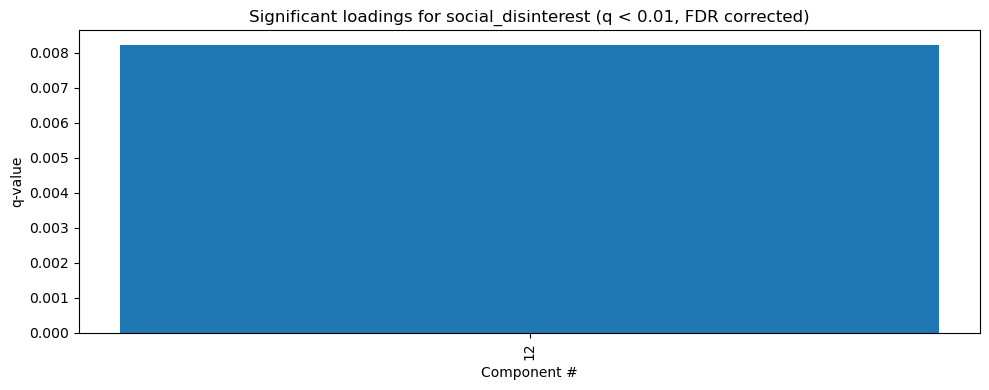

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure no zero q-values (avoid -log10(0) crash)
results["q_social"] = results["q_social"].replace(0, 1e-300)

# --- LOG PLOT (social_disinterest, q-values) ---
plt.figure(figsize=(14, 5))
plt.scatter(results["Loading"], -np.log10(results["q_social"]), s=40)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", label="q = 0.05")
plt.xlabel("Loading Index")
plt.ylabel("-log10(q-value)")
plt.title("-log10(q) for social_disinterest across loadings (FDR corrected)")
plt.legend()
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (social_disinterest) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_social"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for social_disinterest across loadings")
plt.tight_layout()
plt.show()

# --- Significant q < 0.05 ---
sig = results[results["q_social"] < 0.05]
sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_social"])
plt.xticks(rotation=90)
plt.title("Significant loadings for social_disinterest (q < 0.05, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

# --- Significant q < 0.01 ---
sig = results[results["q_social"] < 0.01]
sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_social"])
plt.xticks(rotation=90)
plt.title("Significant loadings for social_disinterest (q < 0.01, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()


In [80]:
# run CoM matrix regressions, generate p and q values
#nothing survives FDR correction

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from statsmodels.stats.multitest import multipletests

results = []

# Loop over upper triangle only (j > i)
for i in range(68):
    for j in range(i + 1, 68):

        # Extract subject-level CoM values for this edge  
        df["CoM_val"] = all_matrices_dep[i, j, :]

        # Regression formula with all 3 factors
        formula = (
            "CoM_val ~ age + C(sex_coded) + C(Location_ID) + "
            "worry_rumination + moodiness + social_disinterest"
        )

        # Fit model
        model = ols(formula, data=df).fit()
        anova = sm.stats.anova_lm(model, typ=2)

        # Extract p-values (from ANOVA)
        p_worry = float(anova.loc["worry_rumination", "PR(>F)"])
        p_mood = float(anova.loc["moodiness", "PR(>F)"])
        p_social = float(anova.loc["social_disinterest", "PR(>F)"])

        # Extract T-statistics (from model coefficients)
        T_worry = float(model.tvalues["worry_rumination"])
        T_mood = float(model.tvalues["moodiness"])
        T_social = float(model.tvalues["social_disinterest"])

        # Store results
        results.append([
            i+1, j+1,
            p_worry, T_worry,
            p_mood, T_mood,
            p_social, T_social
        ])

# Convert to DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Row", "Col",
        "p_worry", "T_worry",
        "p_mood", "T_mood",
        "p_social", "T_social"
    ]
)

# --- FDR correction (Benjamini–Hochberg) ---
results_df["q_worry"] = multipletests(results_df["p_worry"], method='fdr_bh')[1]
results_df["q_mood"] = multipletests(results_df["p_mood"], method='fdr_bh')[1]
results_df["q_social"] = multipletests(results_df["p_social"], method='fdr_bh')[1]

print(results_df)


      Row  Col   p_worry   T_worry    p_mood    T_mood  p_social  T_social  \
0       1    2  0.650673  0.452885  0.321829  0.990913  0.577806 -0.556669   
1       1    3  0.611171  0.508469  0.869895  0.163809  0.704940 -0.378706   
2       1    4  0.066007 -1.839223  0.373539  0.890032  0.283655 -1.072386   
3       1    5  0.236525 -1.184017  0.364372 -0.907240  0.067653 -1.828143   
4       1    6  0.603169  0.519918  0.022579  2.281965  0.124506 -1.536673   
...   ...  ...       ...       ...       ...       ...       ...       ...   
2273   65   67  0.946314 -0.067343  0.183638  1.330023  0.436356 -0.778493   
2274   65   68  0.388854 -0.861856  0.572996  0.563723  0.300803 -1.034938   
2275   66   67  0.672310  0.423032  0.019610  2.335306  0.996844 -0.003956   
2276   66   68  0.600505  0.523745  0.943957 -0.070305  0.966380 -0.042154   
2277   67   68  0.614639 -0.503529  0.509500  0.659716  0.543710  0.607300   

       q_worry    q_mood  q_social  
0     0.977456  0.884491  

In [81]:
import numpy as np

def build_p_matrix(results_df, p_col, n=68, alpha=0.05):
    """
    Build a p-value matrix for CoM edges.

    Lower triangle: all p-values
    Upper triangle: only significant p-values (p < alpha)
    """

    results_df = results_df.copy()

    # Initialize matrix
    p_matrix = np.full((n, n), np.nan)

    # Fill lower triangle with all p-values
    for _, row in results_df.iterrows():
        i = int(row["Row"]) - 1
        j = int(row["Col"]) - 1
        p = row[p_col]

        if j < i:   # lower triangle
            p_matrix[i, j] = p

    # Fill upper triangle with significant p-values only
    for _, row in results_df.iterrows():
        i = int(row["Row"]) - 1
        j = int(row["Col"]) - 1
        p = row[p_col]

        if j > i:   # upper triangle
            p_matrix[i, j] = p if p < alpha else np.nan

    # Diagonal stays empty
    np.fill_diagonal(p_matrix, np.nan)

    return p_matrix


In [83]:
def plot_p_matrix(p_matrix, title, clean_labels):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        p_matrix,
        cmap="viridis_r",
        vmin=0,
        vmax=0.05,      # p < .05 threshold visualization
        mask=np.isnan(p_matrix)
    )

    plt.title(title, fontsize=16)

    plt.xticks(
        ticks=np.arange(68) + 0.5,
        labels=clean_labels,
        rotation=90,
        fontsize=8
    )
    plt.yticks(
        ticks=np.arange(68) + 0.5,
        labels=clean_labels,
        rotation=0,
        fontsize=8
    )

    plt.xlabel("Components (1–68)", fontsize=12)
    plt.ylabel("Components (1–68)", fontsize=12)
    plt.tight_layout()
    plt.show()


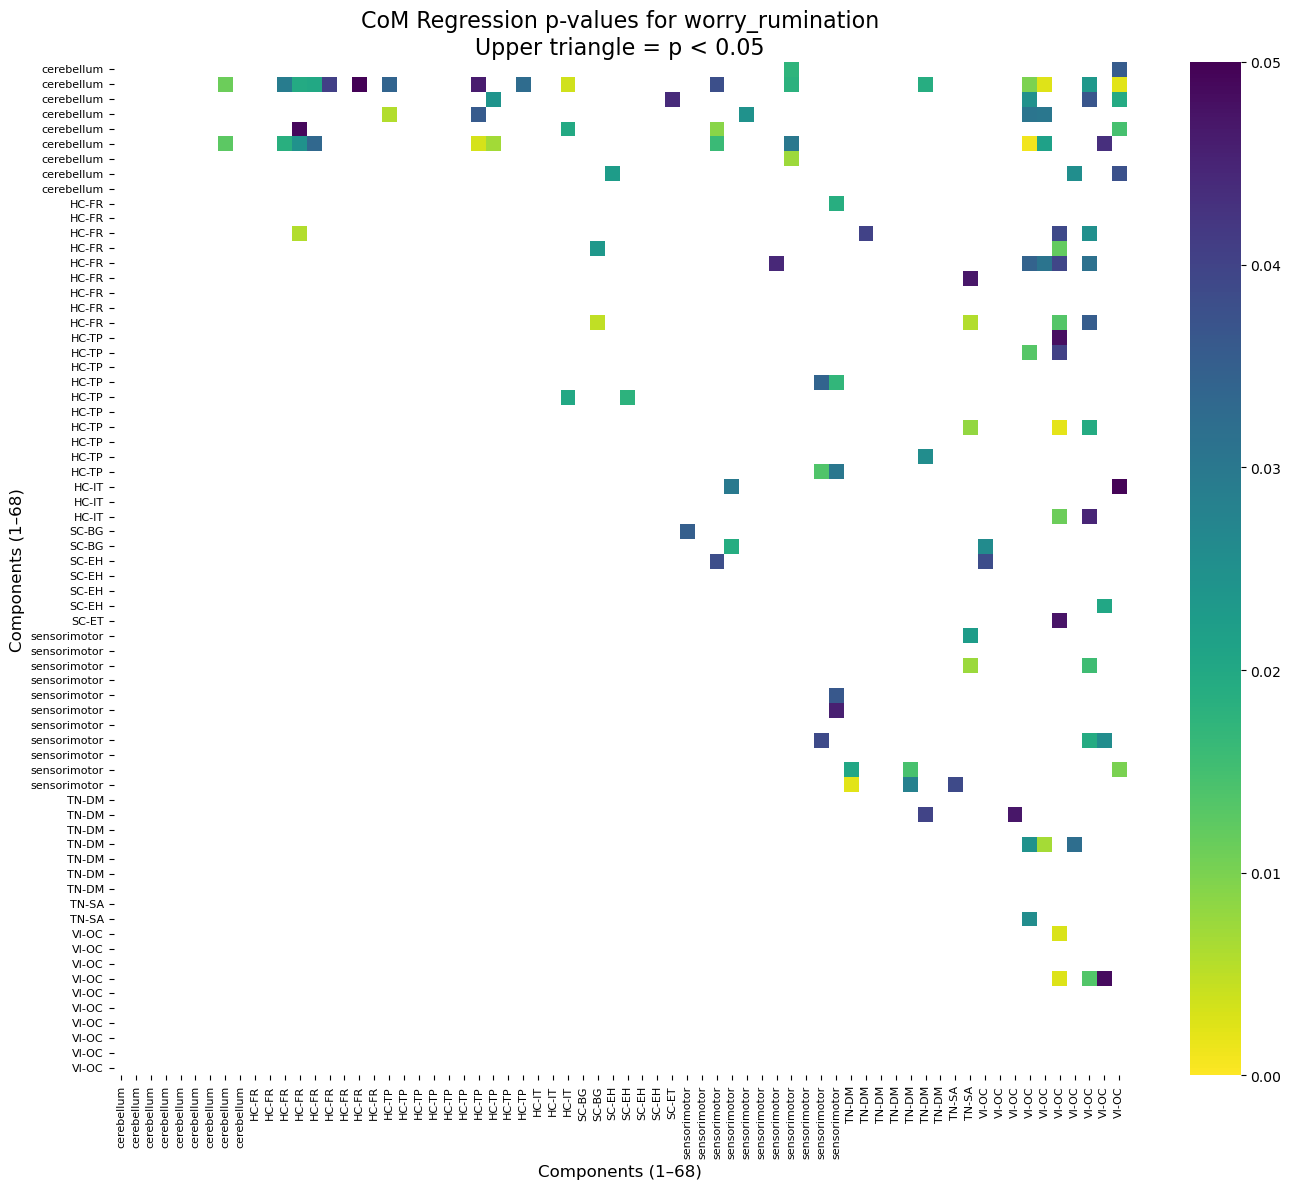

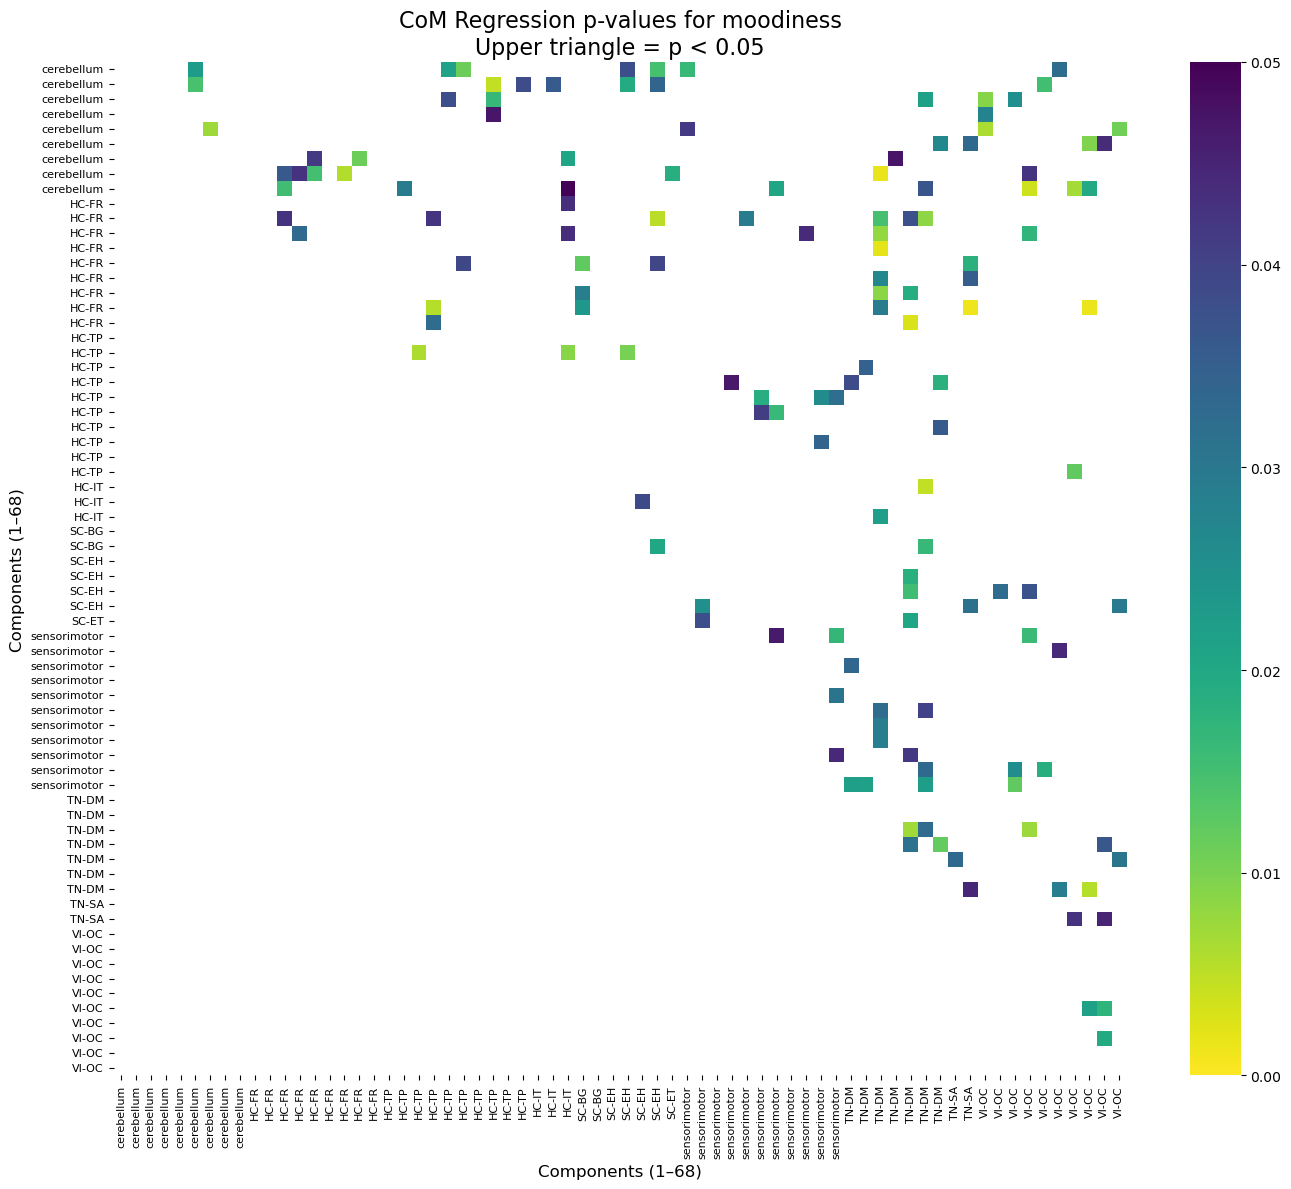

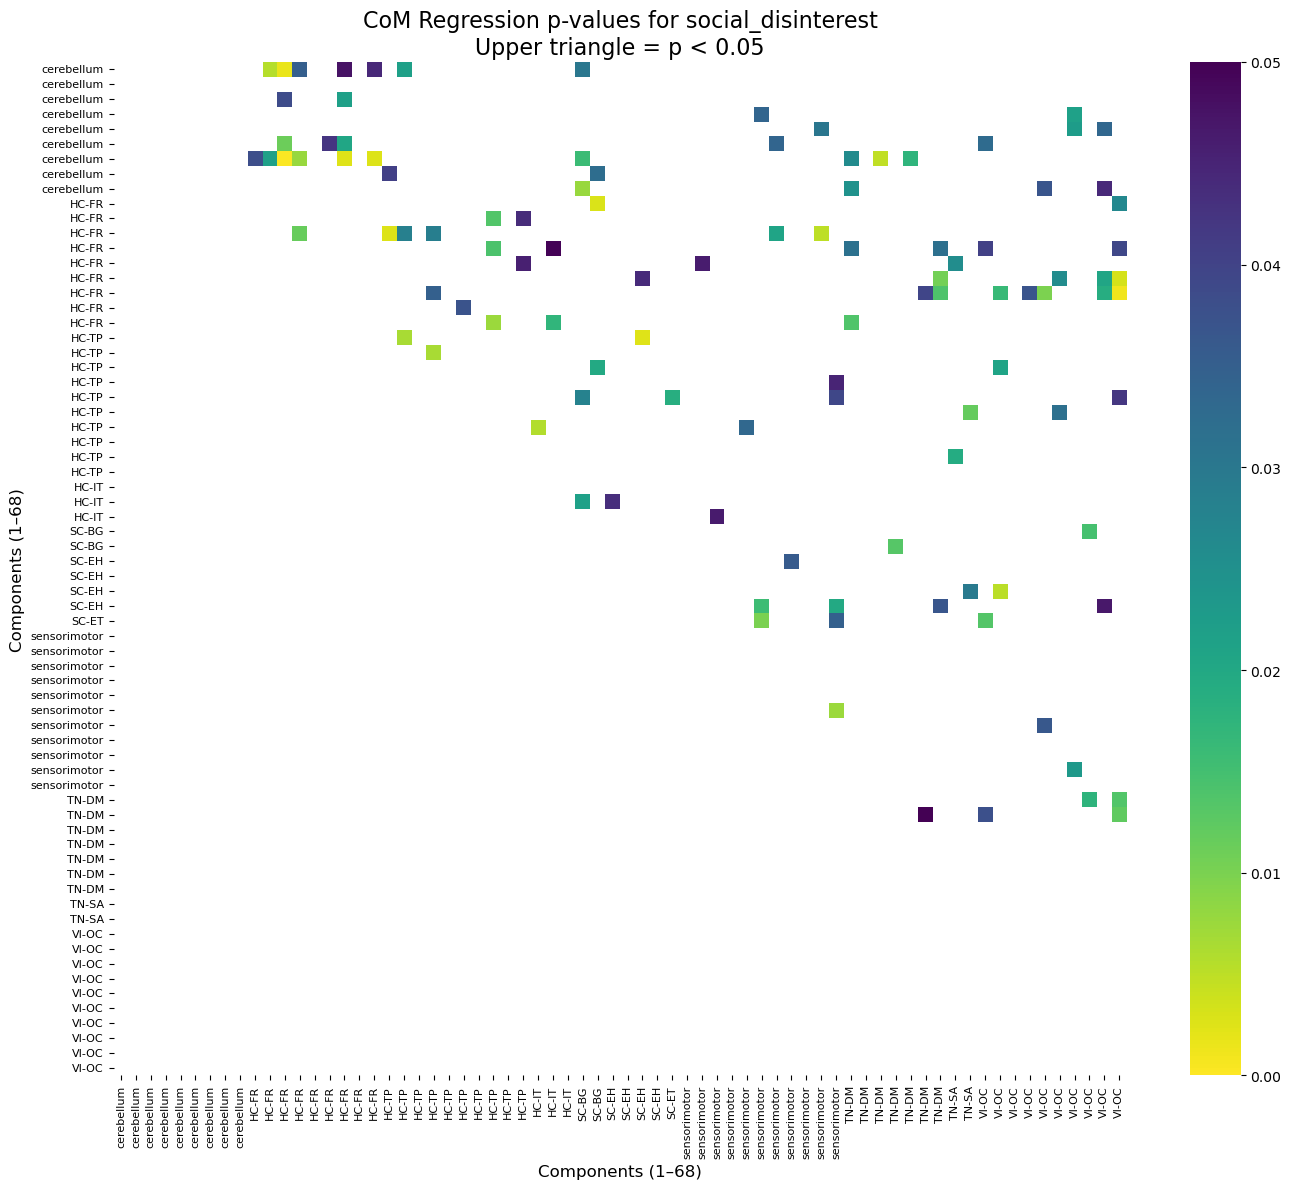

In [84]:
# heatmaps for worry, moodiness, and social disinterest (p-values)

# worry
p_matrix_worry = build_p_matrix(results_df, "p_worry")

plot_p_matrix(
    p_matrix_worry,
    "CoM Regression p-values for worry_rumination\nUpper triangle = p < 0.05",
    clean_labels
)

# moodiness
p_matrix_mood = build_p_matrix(results_df, "p_mood")

plot_p_matrix(
    p_matrix_mood,
    "CoM Regression p-values for moodiness\nUpper triangle = p < 0.05",
    clean_labels
)

# social disinterest
p_matrix_social = build_p_matrix(results_df, "p_social")

plot_p_matrix(
    p_matrix_social,
    "CoM Regression p-values for social_disinterest\nUpper triangle = p < 0.05",
    clean_labels
)
